<a href="https://colab.research.google.com/github/atanilson/Comp702/blob/main/Comp702_APP_MVP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Installing the necessary libraries

In [1]:
%%capture
#!pip -q install --upgrade folium
#!pip -q install geopandas
!pip -q install geojson
#!pip -q install geemap
!pip -q install rasterio
#!pip -q install tqdm
!pip -q install eeconvert

#Panel interactively
!pip install jupyter_bokeh

In [2]:
# Standard imports
import os
from tqdm.auto import tqdm
import requests
import json

import pandas as pd
import numpy as np
from PIL import Image

# Geospacial processing packages
import geopandas as gpd
import geojson

import shapely
import rasterio as rio
from rasterio.plot import show
import rasterio.mask
from shapely.geometry import box

# Mapping and plotting libraries
import matplotlib.pyplot as plt
import matplotlib.colors as cl
import ee
import eeconvert as eec
import geemap
#import geemap.eefolium as emap # Commented out the old import
#import geemap.folium as emap # Added the new import
import folium

# Model
import torch
from torchvision import datasets, models, transforms

In [25]:
# Connecting to colab

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Geeting boundadies

# Area of interest and admin level
AOI = "GBR"
ADM = "ADM3"

# Query geoBoundaries
url = f"https://www.geoboundaries.org/api/current/gbOpen/{AOI}/{ADM}"

r = requests.get(url)
download_path = r.json()["gjDownloadURL"]

# Save the results as a GeoJSON
filename = "geoboundary.geojson"
geoboundary = requests.get(download_path).json()
with open(filename, "w") as file:
    geojson.dump(geoboundary, file)

<Axes: >

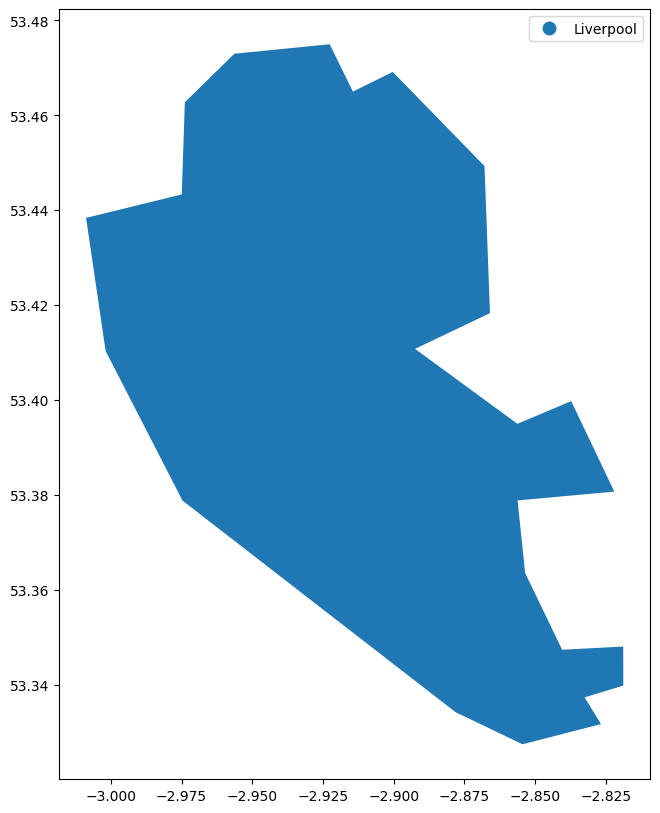

In [5]:
shape_name = "Liverpool"

# Load the GeoJSON data into a GeoDataFrame
geoboundary_gdf = gpd.read_file(filename)

fig, ax = plt.subplots(1, figsize=(10,10))
geoboundary_gdf[geoboundary_gdf.shapeName == shape_name].plot("shapeName", legend=True, ax=ax)

In [6]:
region = geoboundary_gdf.loc[geoboundary_gdf.shapeName == shape_name]
centroid = region.iloc[0].geometry.centroid.coords[0]

In [7]:
# Reading Tiles

In [8]:
save_dir = "./drive/My Drive/Colab Notebooks/Comp702/Files/"
tiles = gpd.read_file(save_dir+"Liverpool20250712.shp")

In [18]:
# LULC Classes
classes = [
    "AnnualCrop",
    "Forest",
    "HerbaceousVegetation",
    "Highway",
    "Industrial",
    "Pasture",
    "PermanentCrop",
    "Residential",
    "River",
    "SeaLake"
]

In [36]:
from typing import List
# Instantiate map centered on the centroid
def folium_Map(classes: List = classes):
  map = folium.Map(location=[centroid[1], centroid[0]], zoom_start=10,world_copy_jump=True)

  colors = {
  'AnnualCrop' : 'lightgreen',
  'Forest' : 'forestgreen',
  'HerbaceousVegetation' : 'yellowgreen',
  'Highway' : 'gray',
  'Industrial' : 'red',
  'Pasture' : 'mediumseagreen',
  'PermanentCrop' : 'chartreuse',
  'Residential' : 'magenta',
  'River' : 'dodgerblue',
  'SeaLake' : 'blue',
  'Error' : 'black'
}

  classes_plot = {}
  for classe in classes:
    classes_plot[classe] = colors[classe]

  # Add Google Satellite basemap
  folium.TileLayer(
        tiles = 'https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}',
        attr = 'Google',
        name = 'Google Satellite',
        overlay = True,
        control = True
  ).add_to(map)

  # Add LULC Map with legend
  legend_txt = '<span style="color: {col};">{txt}</span>'
  for label, color in classes_plot.items():

    # Specify the legend color
    name = legend_txt.format(txt=label, col=color)
    feat_group = folium.FeatureGroup(name=name)

    # Add GeoJSON to feature group
    subtiles = tiles[tiles.pred==label]
    if len(subtiles) > 0:
      folium.GeoJson(
          subtiles,
          style_function=lambda feature: {
            'fillColor': feature['properties']['color'],
            'color': 'black',
            'weight': 0,
            'fillOpacity': 0.5,
          },
          name='LULC Map'
      ).add_to(feat_group)
      map.add_child(feat_group)

  folium.LayerControl().add_to(map)
  return map

In [37]:
folium_Map(["Industrial",'Residential'])

In [11]:
import panel as pn
pn.extension()

In [39]:
def update_map(lista, width=500, height=500):
    # Filter the DataFrame for the selected country
    folium_map = folium_Map(lista)
    # Panel doesn't directly render Folium maps, so we need to render it as HTML
    return pn.pane.HTML(folium_map._repr_html_(), width=width, height=height)

In [40]:
# Park Types
lulc_list = sorted(classes)
lulc_cbg = pn.widgets.CheckBoxGroup(name="lulcs", value=lulc_list, options=lulc_list)

In [41]:
#Filsters
filters = pn.Column(
    lulc_cbg
)

In [42]:
main_map = pn.bind(update_map,  lulc_cbg, 500, 500)

In [43]:
dashboard = pn.Row(
    filters,
    main_map
)

In [44]:
dashboard.servable()

Row
    [0] Column
        [0] CheckBoxGroup(name='lulcs', options=['AnnualCrop', ...], value=['AnnualCrop', ...])
    [1] ParamFunction(function, _pane=HTML, defer_load=False)